# Econometrics I

```
TA Christian Alemán
```

**Session 5: Friday 18, February 2022**

**Activity 1: Simulating Consistency of OLS**

Consider the model

$$y_{i} = \beta_{0}+\beta_{1}x_{i}+\epsilon_{i}$$

$$x\sim U[a,b]$$

We will show consistency of $\beta_{1}^{OLS}$

$$E(\hat{\beta}_{1}|X) = \beta_{1}$$

Let's assume different distributions of $\epsilon$

1. Normal : $\epsilon \sim \mathcal{N}(0,\sigma^{2})$
2. Poisson: $\epsilon \sim Pois(\lambda)$
3. Pareto: $\epsilon \sim Pareto(x_{m},\alpha)$

We will Simulate a population of 100000

Make 10000 draws of sample of n = [25,100,1000,10000];

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


def sim_poisson(N, lam, rng):
    '''
    This function simulates a vector data for the generalized Poisson Distribution using the inverse
    CDF method:

    Inputs:
    N: Number of observations to be simulated
    lambda: Poisson rate

    Output:
    data: NX1 vector of data
    '''
    var_x = rng.random(N)
    return stats.poisson.ppf(var_x, lam)


def sim_gp(N, k, sigma, theta, rng):
    '''
    This function simulates a vector data for the generalized Pareto using the inverse
    CDF method:

    Inputs:
    N     : Number of observations to be simulated
    k     : Index Shape
    sigma : Scale
    theta : Threshold location

    Output:
    data  : NX1 vector of data

    With shape > 0 and location = scale / shape
    the GPD is equivalent to the Pareto distribution with scale x_m = scale / shape
    and shape alpha = 1 / shape
    '''
    var_x = rng.random(N)
    return sigma / k * ((1 - var_x) ** (-k) - 1) + theta


# Parameters
N = 100_000        # Population
n_ms = 10_000       # Number of MC simulations
n_grid = [25, 100, 1000, 10000]   # Sample size
beta0 = 1.0
beta1 = 2.0

# Parameters distributions of epsilon:
sigma = 1.0        # Standard deviation normal
lam = 1.0          # Poisson Rate
k_gp = 1.0         # Shape, if >=1 variance is infinite
sigma_gp = 2.0     # Scale
theta_gp = 0.0
ub, lb = 100.0, 0.0

# Generate population
e_pop = np.empty((N, 3))

rng = np.random.default_rng(124)
e_pop[:, 0] = sigma * rng.standard_normal(N)
e_pop[:, 0] -= e_pop[:, 0].mean()   # demean

rng = np.random.default_rng(125)
e_pop[:, 1] = sim_poisson(N, lam, rng)
e_pop[:, 1] -= e_pop[:, 1].mean()

rng = np.random.default_rng(126)
e_pop[:, 2] = stats.genpareto.rvs(c=k_gp, loc=theta_gp, scale=sigma_gp, size=N, random_state=rng)
e_pop[:, 2] -= e_pop[:, 2].mean()

rng = np.random.default_rng(999)
x_pop = rng.uniform(lb, ub, N)
y_pop = beta0 + beta1 * x_pop[:, None] + e_pop


In [2]:
# Here we do the sampling and compute the distributions of parameters

hbeta1 = np.empty((n_ms, 4, 3))

# Generate n_ms number of samples from the universe.
for i in range(3):        # Distributions
    for ii in range(4):   # Sample sizes
        n = n_grid[ii]
        for j in range(n_ms):
            I_sample = rng.choice(N, size=n, replace=False)
            x_sample = x_pop[I_sample]
            y_sample = y_pop[I_sample, i]
            # Run regression (closed-form simple OLS slope)
            xbar, ybar = x_sample.mean(), y_sample.mean()
            hbeta1[j, ii, i] = np.sum((x_sample - xbar) * (y_sample - ybar)) / np.sum((x_sample - xbar) ** 2)


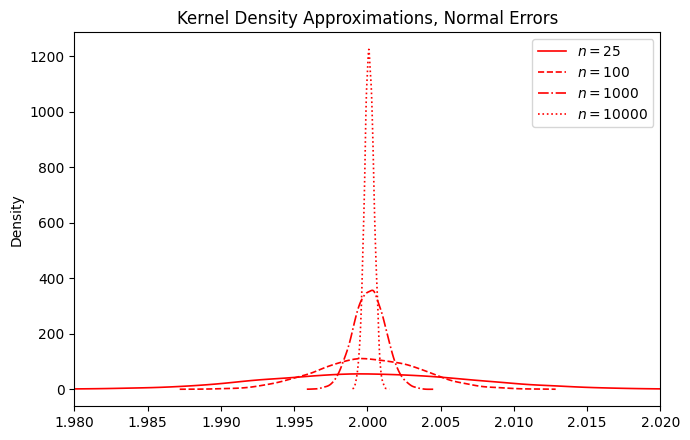

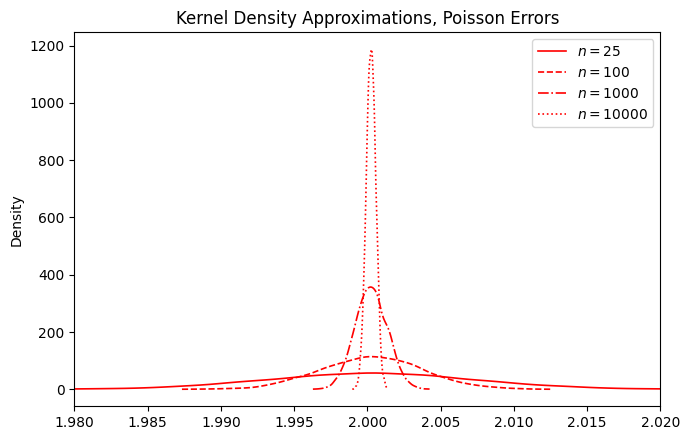

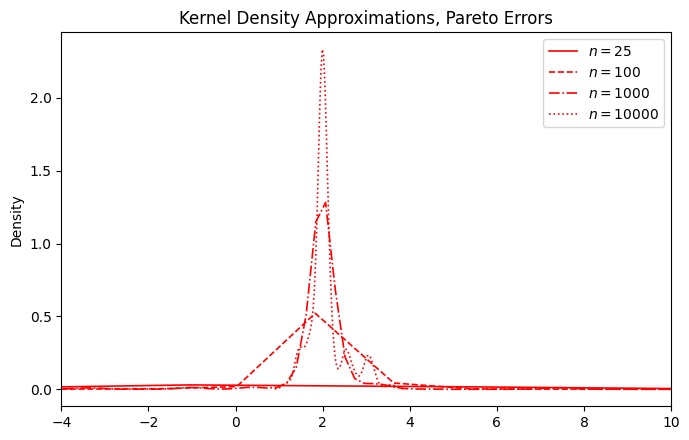

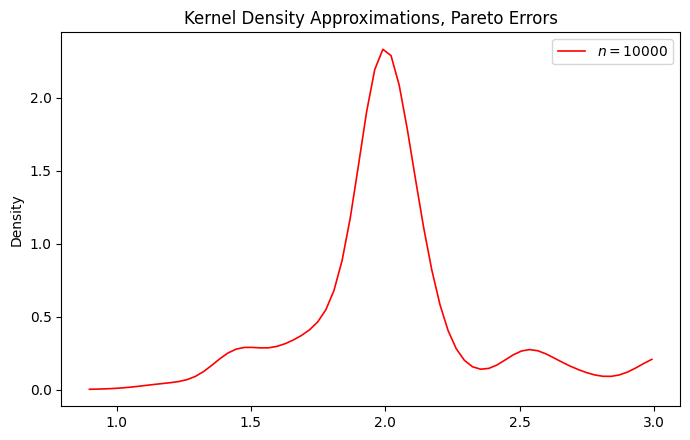

In [3]:
kdensity = np.empty((100, 4, 3))       # Initialize Kernel Density
support = np.empty((100, 4, 3))

for i in range(3):        # Distributions
    for ii in range(4):   # Sample sizes
        data = hbeta1[:, ii, i]
        support[:, ii, i] = np.linspace(data.min(), data.max(), 100)
        kde = stats.gaussian_kde(data)
        kdensity[:, ii, i] = kde(support[:, ii, i])

styles = ['r-', 'r--', 'r-.', 'r:']
labels = ['$n=25$', '$n=100$', '$n=1000$', '$n=10000$']

fig, ax = plt.subplots(figsize=(7, 4.5))
for ii in range(4):
    ax.plot(support[:, ii, 0], kdensity[:, ii, 0], styles[ii], linewidth=1.2, label=labels[ii])
ax.set_xlim(1.98, 2.02)
ax.set_title('Kernel Density Approximations, Normal Errors')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
for ii in range(4):
    ax.plot(support[:, ii, 1], kdensity[:, ii, 1], styles[ii], linewidth=1.2, label=labels[ii])
ax.set_xlim(1.98, 2.02)
ax.set_title('Kernel Density Approximations, Poisson Errors')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
for ii in range(4):
    ax.plot(support[:, ii, 2], kdensity[:, ii, 2], styles[ii], linewidth=1.2, label=labels[ii])
ax.set_xlim(-4, 10)
ax.set_title('Kernel Density Approximations, Pareto Errors')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(support[:70, 3, 2], kdensity[:70, 3, 2], 'r-', linewidth=1.2, label='$n=10000$')
ax.set_title('Kernel Density Approximations, Pareto Errors')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()


**Activity 1.1: Asymptotic Normality**

Normality test for the last case H0: x comes from a standard normal distribution

In [4]:
name = ['Normal:', 'Poisson:', 'Pareto:']
for i in range(3):
    print(name[i])
    data = hbeta1[:, 3, i]
    mu_hat, sigma_hat = data.mean(), data.std(ddof=1)
    stat, pval = stats.kstest(data, 'norm', args=(mu_hat, sigma_hat))
    h = pval < 0.05   # Test if the data are from the hypothesized distribution.
    if h:
        print('We reject the Null: Then distribution is not normal')
    else:
        print('We CANNOT reject the Null: Then distribution is normal')


Normal:
We CANNOT reject the Null: Then distribution is normal
Poisson:
We CANNOT reject the Null: Then distribution is normal
Pareto:
We reject the Null: Then distribution is not normal


**Activity 2: Testing Non Linear Constraints WALD test**

Consider the following consumption function with different short- and long-run marginal propensities to consume (MPC).

$$lnC_{t}=\beta_{1}+\beta_{2}lnY_{t}+\beta_{3}lnC_{t-1}+\epsilon_{t}$$

1. $C_{t}$ is Consumption at $t$ (in real USD)
2. $Y_{t}$ is Disposable Income at $t$ (in real USD)

1. $\beta_{2}$: Short Run MPC
2. $\frac{\beta_{2}}{1-\beta_{3}}=\gamma$: Long Run MPC

We are interested in knowing whether $\gamma=1$

In [5]:
data_income = pd.read_csv('income2.csv', header=None).to_numpy()
'''
1: C0
2: C1
3: Y
'''
data_income = np.log(data_income)
n = data_income.shape[0]
K = 3
X = np.column_stack([np.ones(n), data_income[:, 2], data_income[:, 1]])
y = data_income[:, 0]

# Compute OLS
betas = np.linalg.inv(X.T @ X) @ (X.T @ y)
hgamma = betas[1] / (1 - betas[2])

Param = ['beta 1', 'beta 2', 'beta 3', 'gamma']
hat_betas = np.append(betas, hgamma)
tab_B = pd.DataFrame({'Param': Param, 'hat_betas': hat_betas})
print('OLS Estimates:')
print(tab_B.to_string(index=False))


OLS Estimates:
 Param  hat_betas
beta 1   0.003142
beta 2   0.074958
beta 3   0.924625
 gamma   0.994461


Predict errors

In [6]:
he = y - X @ betas
hsigma = (he @ he) / (n - K)
# Compute Asymptotic VarCovar
Avar_beta = hsigma * np.linalg.inv(X.T @ X)
AVCV = np.sqrt(np.diag(Avar_beta))     # Variance Covariance

# Compute the analytical derivatives:
# Derivative: d(beta2/(1-beta3))/d(beta)
grad = np.array([0.0, 1 / (1 - betas[2]), betas[1] / (1 - betas[2]) ** 2])
# Compute the asymptotic Variance
Avar_Cbeta = grad @ Avar_beta @ grad
# Since we are testing one restriction we compute the z-score:
# H0: gamma = 1
z = (hgamma - 1) / np.sqrt(Avar_Cbeta)
print(f'Z-Score = {z:.5g}')
print('We cannot reject gamma=1')


Z-Score = -0.33863
We cannot reject gamma=1


**Activity 3: Bootstrap standard errors**

**3.1 Non-Parametric Bootstrap**

1. Generate B samples with replacement of pairs $(y_{i},x_{i})$
2. Estimate the bootstrap $\hat{\beta}$ by fitting the model
3. Compute the standard errors

In [7]:
n = n_grid[2]      # Sample size
K = 2
x = 1 + 2 * rng.standard_normal((n, 2))
x[:, 0] = 4 + x[:, 0]
e = 2 * rng.standard_normal(n)
y = x @ np.ones(2) + e

hbeta = np.linalg.inv(x.T @ x) @ (x.T @ y)
ehat = y - x @ hbeta
B = 1000

hbeta_sample = np.empty((B, K))
for i in range(B):
    I_sample = rng.integers(0, n, size=n)
    ysample = y[I_sample]
    xsample = np.column_stack([x[I_sample, 0], x[I_sample, 1]])
    hbeta_sample[i, :] = np.linalg.inv(xsample.T @ xsample) @ (xsample.T @ ysample)

diff = hbeta_sample - hbeta
bootVCV = (diff.T @ diff) / B
OLSVCV = (e @ e) / n * np.linalg.inv(x.T @ x)

SEbeta_hat_OLS = np.sqrt(np.diag(OLSVCV))
SEbeta_hat_boot = np.sqrt(np.diag(bootVCV))

Param = ['beta 0', 'beta 1']
tab_SE = pd.DataFrame({'Param': Param, 'SE_OLS': SEbeta_hat_OLS, 'SE_Bootstrap': SEbeta_hat_boot})
print('Non-Parametric Standard Errors:')
print(tab_SE.to_string(index=False))


Non-Parametric Standard Errors:
 Param   SE_OLS  SE_Bootstrap
beta 0 0.012750      0.012910
beta 1 0.031552      0.032342


**3.2 Parametric Bootstrap**

1. Generate 2*B samples with replacement of $e_{i},x_{i}$ independently
2. Construct values of $y$
3. Estimate the bootstrap $\hat{\beta}$ by fitting the model
4. Compute the standard errors

In [8]:
for i in range(B):
    I_sample = rng.integers(0, n, size=n)
    II_sample = rng.integers(0, n, size=n)
    esample = ehat[I_sample]
    xsample = np.column_stack([x[I_sample, 0], x[I_sample, 1]])
    ysample = xsample @ hbeta + esample
    hbeta_sample[i, :] = np.linalg.inv(xsample.T @ xsample) @ (xsample.T @ ysample)

diff = hbeta_sample - hbeta
bootVCV = (diff.T @ diff) / B
OLSVCV = (e @ e) / n * np.linalg.inv(x.T @ x)

SEbeta_hat_OLS = np.sqrt(np.diag(OLSVCV))
SEbeta_hat_boot = np.sqrt(np.diag(bootVCV))

tab_SE = pd.DataFrame({'Param': Param, 'SE_OLS': SEbeta_hat_OLS, 'SE_Bootstrap': SEbeta_hat_boot})
print('Parametric Standard Errors:')
print(tab_SE.to_string(index=False))


Parametric Standard Errors:
 Param   SE_OLS  SE_Bootstrap
beta 0 0.012750      0.012816
beta 1 0.031552      0.030753


This markdown was constructed based on the IPYNB code below.

In [9]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy import stats
#
#
# def sim_poisson(N, lam, rng):
#     '''
#     This function simulates a vector data for the generalized Poisson Distribution using the inverse
#     CDF method:
#
#     Inputs:
#     N: Number of observations to be simulated
#     lambda: Poisson rate
#
#     Output:
#     data: NX1 vector of data
#     '''
#     var_x = rng.random(N)
#     return stats.poisson.ppf(var_x, lam)
#
#
# def sim_gp(N, k, sigma, theta, rng):
#     '''
#     This function simulates a vector data for the generalized Pareto using the inverse
#     CDF method:
#
#     Inputs:
#     N     : Number of observations to be simulated
#     k     : Index Shape
#     sigma : Scale
#     theta : Threshold location
#
#     Output:
#     data  : NX1 vector of data
#
#     With shape > 0 and location = scale / shape
#     the GPD is equivalent to the Pareto distribution with scale x_m = scale / shape
#     and shape alpha = 1 / shape
#     '''
#     var_x = rng.random(N)
#     return sigma / k * ((1 - var_x) ** (-k) - 1) + theta
#
#
# # Parameters
# N = 100_000        # Population
# n_ms = 10_000       # Number of MC simulations
# n_grid = [25, 100, 1000, 10000]   # Sample size
# beta0 = 1.0
# beta1 = 2.0
#
# # Parameters distributions of epsilon:
# sigma = 1.0        # Standard deviation normal
# lam = 1.0          # Poisson Rate
# k_gp = 1.0         # Shape, if >=1 variance is infinite
# sigma_gp = 2.0     # Scale
# theta_gp = 0.0
# ub, lb = 100.0, 0.0
#
# # Generate population
# e_pop = np.empty((N, 3))
#
# rng = np.random.default_rng(124)
# e_pop[:, 0] = sigma * rng.standard_normal(N)
# e_pop[:, 0] -= e_pop[:, 0].mean()   # demean
#
# rng = np.random.default_rng(125)
# e_pop[:, 1] = sim_poisson(N, lam, rng)
# e_pop[:, 1] -= e_pop[:, 1].mean()
#
# rng = np.random.default_rng(126)
# e_pop[:, 2] = stats.genpareto.rvs(c=k_gp, loc=theta_gp, scale=sigma_gp, size=N, random_state=rng)
# e_pop[:, 2] -= e_pop[:, 2].mean()
#
# rng = np.random.default_rng(999)
# x_pop = rng.uniform(lb, ub, N)
# y_pop = beta0 + beta1 * x_pop[:, None] + e_pop
#
#
# # ----- next cell -----
#
# # Here we do the sampling and compute the distributions of parameters
#
# hbeta1 = np.empty((n_ms, 4, 3))
#
# # Generate n_ms number of samples from the universe.
# for i in range(3):        # Distributions
#     for ii in range(4):   # Sample sizes
#         n = n_grid[ii]
#         for j in range(n_ms):
#             I_sample = rng.choice(N, size=n, replace=False)
#             x_sample = x_pop[I_sample]
#             y_sample = y_pop[I_sample, i]
#             # Run regression (closed-form simple OLS slope)
#             xbar, ybar = x_sample.mean(), y_sample.mean()
#             hbeta1[j, ii, i] = np.sum((x_sample - xbar) * (y_sample - ybar)) / np.sum((x_sample - xbar) ** 2)
#
#
# # ----- next cell -----
#
# kdensity = np.empty((100, 4, 3))       # Initialize Kernel Density
# support = np.empty((100, 4, 3))
#
# for i in range(3):        # Distributions
#     for ii in range(4):   # Sample sizes
#         data = hbeta1[:, ii, i]
#         support[:, ii, i] = np.linspace(data.min(), data.max(), 100)
#         kde = stats.gaussian_kde(data)
#         kdensity[:, ii, i] = kde(support[:, ii, i])
#
# styles = ['r-', 'r--', 'r-.', 'r:']
# labels = ['$n=25$', '$n=100$', '$n=1000$', '$n=10000$']
#
# fig, ax = plt.subplots(figsize=(7, 4.5))
# for ii in range(4):
#     ax.plot(support[:, ii, 0], kdensity[:, ii, 0], styles[ii], linewidth=1.2, label=labels[ii])
# ax.set_xlim(1.98, 2.02)
# ax.set_title('Kernel Density Approximations, Normal Errors')
# ax.set_ylabel('Density')
# ax.legend()
# plt.tight_layout()
# plt.show()
#
# fig, ax = plt.subplots(figsize=(7, 4.5))
# for ii in range(4):
#     ax.plot(support[:, ii, 1], kdensity[:, ii, 1], styles[ii], linewidth=1.2, label=labels[ii])
# ax.set_xlim(1.98, 2.02)
# ax.set_title('Kernel Density Approximations, Poisson Errors')
# ax.set_ylabel('Density')
# ax.legend()
# plt.tight_layout()
# plt.show()
#
# fig, ax = plt.subplots(figsize=(7, 4.5))
# for ii in range(4):
#     ax.plot(support[:, ii, 2], kdensity[:, ii, 2], styles[ii], linewidth=1.2, label=labels[ii])
# ax.set_xlim(-4, 10)
# ax.set_title('Kernel Density Approximations, Pareto Errors')
# ax.set_ylabel('Density')
# ax.legend()
# plt.tight_layout()
# plt.show()
#
# fig, ax = plt.subplots(figsize=(7, 4.5))
# ax.plot(support[:70, 3, 2], kdensity[:70, 3, 2], 'r-', linewidth=1.2, label='$n=10000$')
# ax.set_title('Kernel Density Approximations, Pareto Errors')
# ax.set_ylabel('Density')
# ax.legend()
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# name = ['Normal:', 'Poisson:', 'Pareto:']
# for i in range(3):
#     print(name[i])
#     data = hbeta1[:, 3, i]
#     mu_hat, sigma_hat = data.mean(), data.std(ddof=1)
#     stat, pval = stats.kstest(data, 'norm', args=(mu_hat, sigma_hat))
#     h = pval < 0.05   # Test if the data are from the hypothesized distribution.
#     if h:
#         print('We reject the Null: Then distribution is not normal')
#     else:
#         print('We CANNOT reject the Null: Then distribution is normal')
#
#
# # ----- next cell -----
#
# data_income = pd.read_csv('income2.csv', header=None).to_numpy()
# '''
# 1: C0
# 2: C1
# 3: Y
# '''
# data_income = np.log(data_income)
# n = data_income.shape[0]
# K = 3
# X = np.column_stack([np.ones(n), data_income[:, 2], data_income[:, 1]])
# y = data_income[:, 0]
#
# # Compute OLS
# betas = np.linalg.inv(X.T @ X) @ (X.T @ y)
# hgamma = betas[1] / (1 - betas[2])
#
# Param = ['beta 1', 'beta 2', 'beta 3', 'gamma']
# hat_betas = np.append(betas, hgamma)
# tab_B = pd.DataFrame({'Param': Param, 'hat_betas': hat_betas})
# print('OLS Estimates:')
# print(tab_B.to_string(index=False))
#
#
# # ----- next cell -----
#
# he = y - X @ betas
# hsigma = (he @ he) / (n - K)
# # Compute Asymptotic VarCovar
# Avar_beta = hsigma * np.linalg.inv(X.T @ X)
# AVCV = np.sqrt(np.diag(Avar_beta))     # Variance Covariance
#
# # Compute the analytical derivatives:
# # Derivative: d(beta2/(1-beta3))/d(beta)
# grad = np.array([0.0, 1 / (1 - betas[2]), betas[1] / (1 - betas[2]) ** 2])
# # Compute the asymptotic Variance
# Avar_Cbeta = grad @ Avar_beta @ grad
# # Since we are testing one restriction we compute the z-score:
# # H0: gamma = 1
# z = (hgamma - 1) / np.sqrt(Avar_Cbeta)
# print(f'Z-Score = {z:.5g}')
# print('We cannot reject gamma=1')
#
#
# # ----- next cell -----
#
# n = n_grid[2]      # Sample size
# K = 2
# x = 1 + 2 * rng.standard_normal((n, 2))
# x[:, 0] = 4 + x[:, 0]
# e = 2 * rng.standard_normal(n)
# y = x @ np.ones(2) + e
#
# hbeta = np.linalg.inv(x.T @ x) @ (x.T @ y)
# ehat = y - x @ hbeta
# B = 1000
#
# hbeta_sample = np.empty((B, K))
# for i in range(B):
#     I_sample = rng.integers(0, n, size=n)
#     ysample = y[I_sample]
#     xsample = np.column_stack([x[I_sample, 0], x[I_sample, 1]])
#     hbeta_sample[i, :] = np.linalg.inv(xsample.T @ xsample) @ (xsample.T @ ysample)
#
# diff = hbeta_sample - hbeta
# bootVCV = (diff.T @ diff) / B
# OLSVCV = (e @ e) / n * np.linalg.inv(x.T @ x)
#
# SEbeta_hat_OLS = np.sqrt(np.diag(OLSVCV))
# SEbeta_hat_boot = np.sqrt(np.diag(bootVCV))
#
# Param = ['beta 0', 'beta 1']
# tab_SE = pd.DataFrame({'Param': Param, 'SE_OLS': SEbeta_hat_OLS, 'SE_Bootstrap': SEbeta_hat_boot})
# print('Non-Parametric Standard Errors:')
# print(tab_SE.to_string(index=False))
#
#
# # ----- next cell -----
#
# for i in range(B):
#     I_sample = rng.integers(0, n, size=n)
#     II_sample = rng.integers(0, n, size=n)
#     esample = ehat[I_sample]
#     xsample = np.column_stack([x[I_sample, 0], x[I_sample, 1]])
#     ysample = xsample @ hbeta + esample
#     hbeta_sample[i, :] = np.linalg.inv(xsample.T @ xsample) @ (xsample.T @ ysample)
#
# diff = hbeta_sample - hbeta
# bootVCV = (diff.T @ diff) / B
# OLSVCV = (e @ e) / n * np.linalg.inv(x.T @ x)
#
# SEbeta_hat_OLS = np.sqrt(np.diag(OLSVCV))
# SEbeta_hat_boot = np.sqrt(np.diag(bootVCV))
#
# tab_SE = pd.DataFrame({'Param': Param, 'SE_OLS': SEbeta_hat_OLS, 'SE_Bootstrap': SEbeta_hat_boot})
# print('Parametric Standard Errors:')
# print(tab_SE.to_string(index=False))